# Multi-Stage Training: Subthreshold (MSE) -> Spiking (Guarino)
Curriculum approach that fits parameters in groups, each stage starting from the
parameters fit in the previous one.

**Subthreshold regime (MSE loss, subthreshold trace):**
1. **Stage 1 (MSE)**: coarsely match `C_m`, `E_L`
2. **Stage 2 (MSE)**: refine `E_L`, `g_L`

**Spiking regime (Guarino feature loss, spiking traces):**
3. **Stage 3 (Guarino)**: spike initiation — `v_T`, `delta_T`, `v_reset`
4. **Stage 4 (Guarino)**: adaptation — `tau_w`, `a`, `b`

The Guarino feature-based loss (soft spike count, spike times, ISIs, firing rate,
subthreshold voltage) is used in the spiking stages because the AdEx reset removes
spike peaks, making raw-voltage MSE a poor signal once the neuron fires.

## Prerequisits

In [1]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley, simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
    make_van_rossum_loss_fn,
    VanRossumLossConfig,
    spike_train_from_voltage,
    make_mse_loss_fn,
    MSELossConfig,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

In [2]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

DATA = {
    'subthreshold': {
        'voltage_path': DATA_DIR + "ECBL_IDthresh_ch5_540.dat",
        'current_path': DATA_DIR + "ECBL_IDthresh_ch4_540.dat",
    },
    'stim1': {
        'voltage_path': DATA_DIR + "ECBL_IDthresh_ch5_545.dat",
        'current_path': DATA_DIR + "ECBL_IDthresh_ch4_545.dat",
    },
    'stim2': {
        'voltage_path': DATA_DIR + "ECBL_IDthresh_ch5_552.dat",
        'current_path': DATA_DIR + "ECBL_IDthresh_ch4_552.dat",
    },   
    'stim3': {
        'voltage_path': DATA_DIR + "ECBL_IDthresh_ch5_557.dat",
        'current_path': DATA_DIR + "ECBL_IDthresh_ch4_557.dat",
    },
}



# Stage 1: Subthreshold fitting
## 1. Load data

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 319.9 pA
Detected spikes: 0


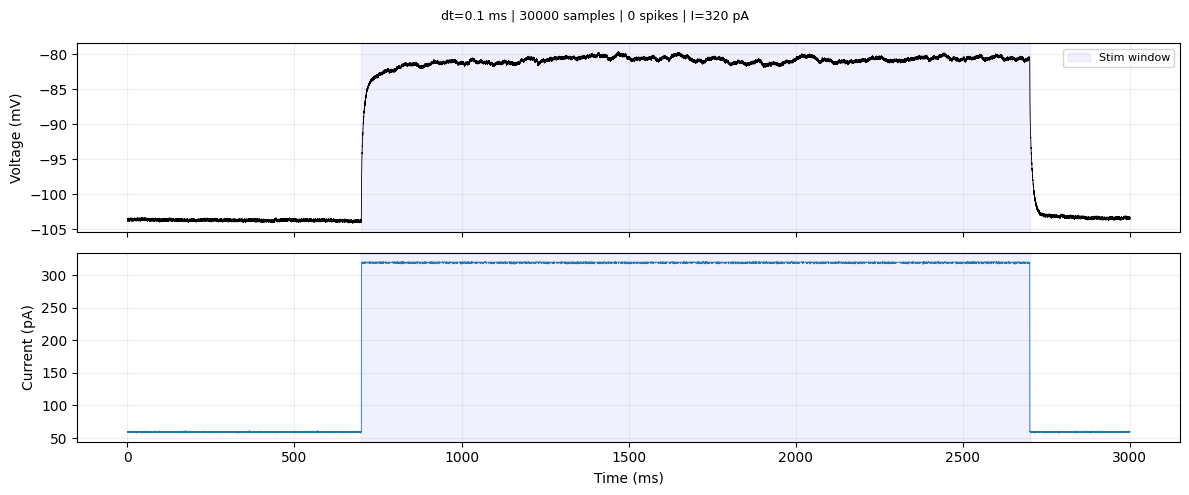

In [3]:
mode = 'subthreshold'

trace = load_trace(
    voltage_path=DATA[mode]['voltage_path'],
    current_path=DATA[mode]['current_path'],
    spike_threshold_mv=-10,
)

trace_plot(trace)

print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")


-103.625
Cropped trace: 1010 samples, 1.0 ms
Spikes in window: 0 at [] ms


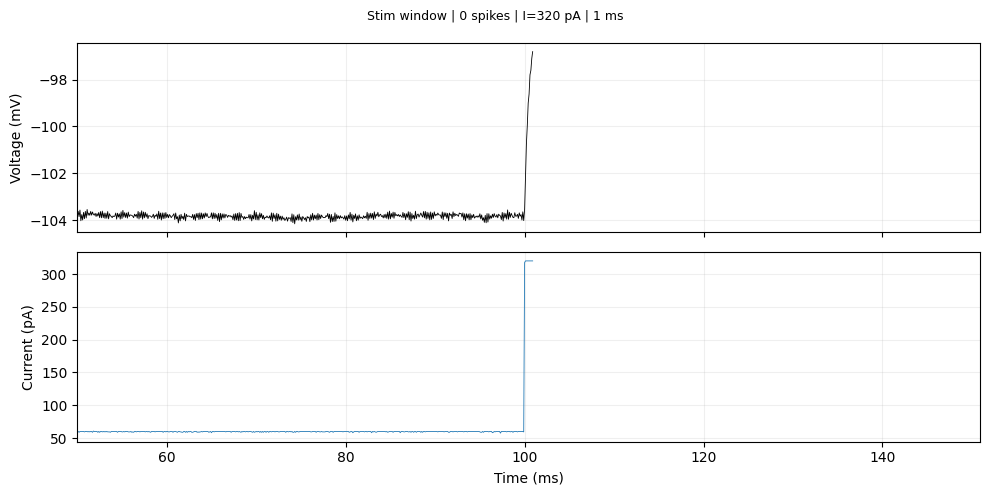

In [4]:
# Crop to stimulation window (500 ms max)
# data = crop_to_stim_window(trace, max_duration_ms=500.0)
data = crop_to_stim_window(
    trace, max_duration_ms=1.0, padding_ms_before=100.0
)

print(data.voltage[10])
print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

INFO:2026-06-15 13:18:14,703:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 0 spikes, firing rate 0.0 Hz
Experimental:       0 spikes
dt_ms: 0.1
{'C_m': 200.0, 'g_L': 10.0, 'E_L': -70.0, 'v_T': 0.0, 'delta_T': 1.0, 'v_reset': -100.0, 'v_threshold': 0.0, 'tau_w': 20.0, 'a': 0.0, 'b': 0.0, 'I': 500.0}


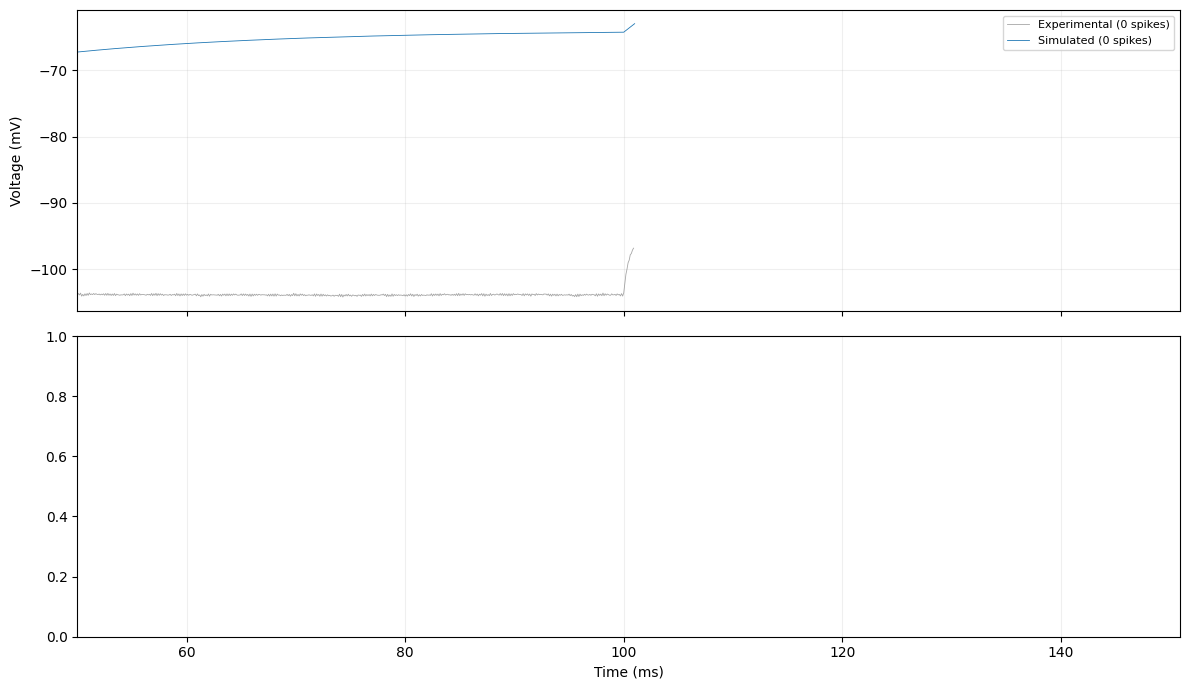

In [5]:
initial_params = dict(NAUD_PARAMETERS["tonic"])

TRAINABLE_STAGE1 = ["C_m", "E_L"] # 

# Default for unknown parameters in non-spiking setting
initial_params["v_T"] = 0.0
initial_params["delta_T"] = 1.0
initial_params["v_reset"] = -100.0
initial_params["tau_w"] = 20.0
initial_params["a"] = 0.0
initial_params["b"] = 0.0

# sim_init = simulate_jaxley(
#     params=initial_params,
#     stim_current_pA=data.stim_current_pA,
#     stim_duration_ms=data.stim_duration_ms,
#     dt_ms=data.dt_ms,
#     use_surrogate=True,
# )

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init)

print(f"dt_ms: {data.dt_ms}")
print(initial_params)

## 3. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [6]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_trace_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
exp_voltage = jnp.array(data.voltage)

# --- Stage 1 config: Polyak optimizer, 300 epochs, sigmoid reparameterization ---
config_stage1 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.1,
    n_epochs=2000,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=100,
    #polyak_alpha=1.0,
    #polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=False,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage1,
    trainable_params=TRAINABLE_STAGE1,
)

loss_fn_stage1 = make_mse_loss_fn(cell=cell1, data_stimuli=data_stimuli1, t_max=t_max1, dt_ms=data.dt_ms, exp_voltage=data.voltage, stim_end_index=data.stim_end_idx)


print(f"Initial MSE loss: {float(loss_fn_stage1(trainable_params1)):.4f}")
print(trainable_params1)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Initial MSE loss: 1113.9188
[{'capacitance': Array([200.], dtype=float32)}, {'AdEx_E_L': Array([-70.], dtype=float32)}]


ALIGNMENT SUMMARY
data.n_samples        = 1010
data.dt_ms            = 0.1
data.duration_ms      = 100.9
data.stim_start_idx   = 1000  (100.0 ms)
data.stim_end_idx     = 1010  (101.0 ms)
data.stim_duration_ms = 1.0
data.stim_current_pA  = 319.9
stim_end_index (loss) = 1010
loss sees voltage[:1010]  (101.0 ms)

Pre-stim:   [0, 1000)  = 100.0 ms
Stim:       [1000, 1010)  = 1.0 ms
Post-stim:  [1010, 1010)  = 0.0 ms

Note: Pre-stim padding (100 ms) is included in both
  simulation and target. Loss functions compare from t=0,
  so spike times include the pre-stim offset in both sim and exp.


/Users/paulmayer/Projects/university/40_thesis/5_code/ADoptEX/plotting.py:237: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="upper right")


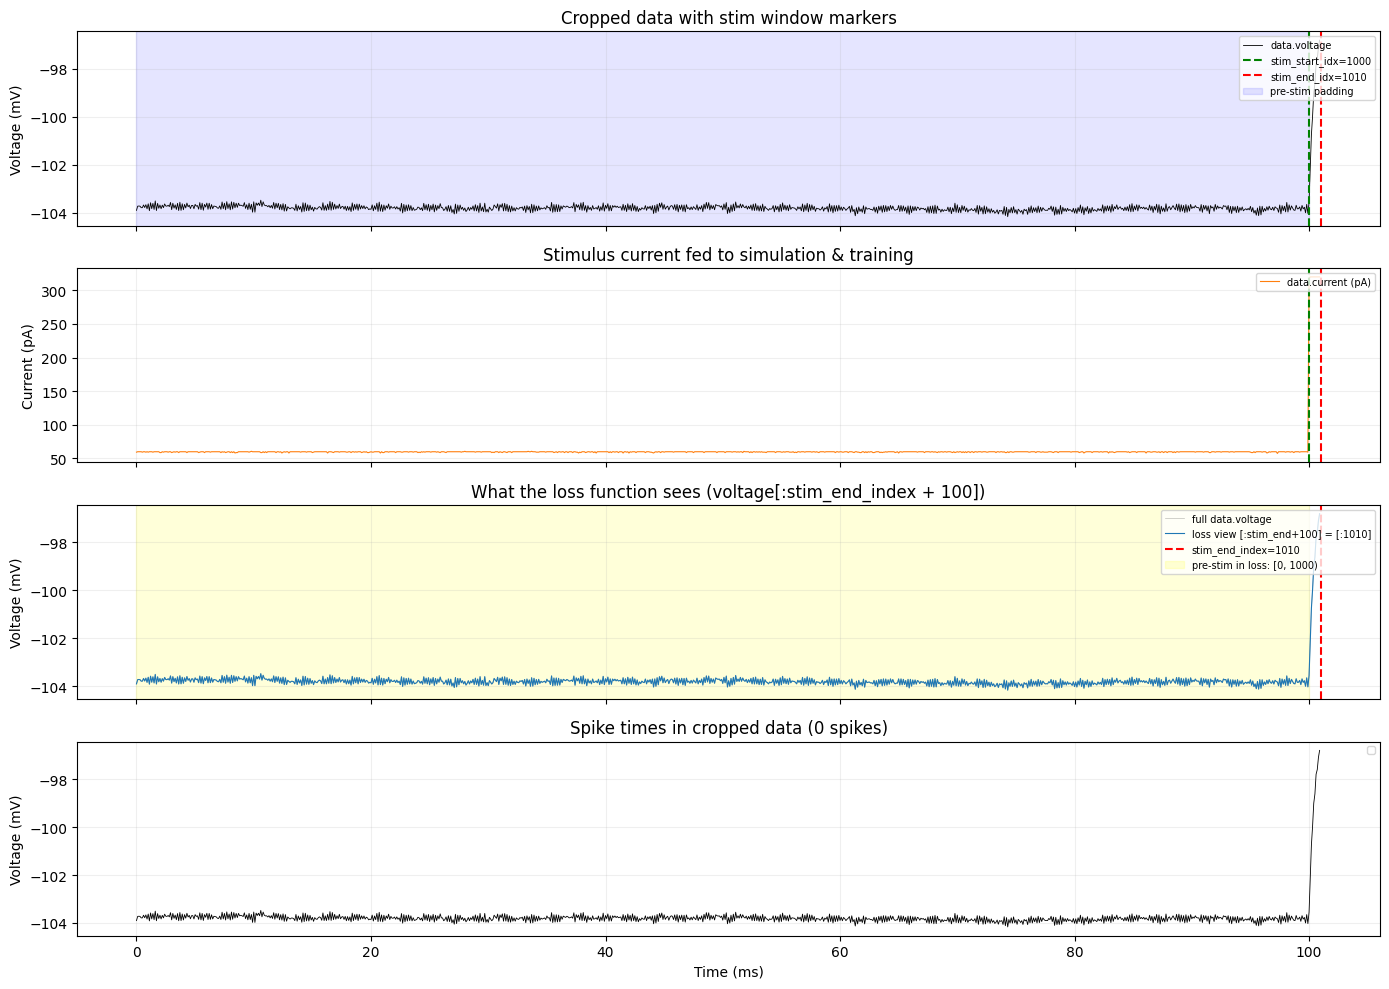

In [7]:
# ── Alignment diagnostic: verify data, stimuli, and loss function alignment ──
from ADoptEX.plotting import alignment_diagnostic_plot

alignment_diagnostic_plot(data, stim_end_index=data.stim_end_idx);

In [8]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")


Training: optimizer=adam lr=0.1 epochs=2000 surrogate=superspike slope=10.0
Epoch    0 | loss=1113.918823 | grad_norm=5.55e+01 | C_m=200.1000, E_L=-70.1000
Epoch  100 | loss=632.523682 | grad_norm=4.16e+01 | C_m=209.1537, E_L=-79.6054
Epoch  200 | loss=334.259674 | grad_norm=3.01e+01 | C_m=215.6272, E_L=-87.6967
Epoch  300 | loss=162.732147 | grad_norm=2.10e+01 | C_m=219.7560, E_L=-94.3010
Epoch  400 | loss=72.098175 | grad_norm=1.39e+01 | C_m=222.0942, E_L=-99.4457
Epoch  500 | loss=28.800539 | grad_norm=8.77e+00 | C_m=223.2620, E_L=-103.2373
Epoch  600 | loss=10.329491 | grad_norm=5.22e+00 | C_m=223.7751, E_L=-105.8624
Epoch  700 | loss=3.377982 | grad_norm=2.92e+00 | C_m=223.9733, E_L=-107.5615
Epoch  800 | loss=1.079584 | grad_norm=1.54e+00 | C_m=224.0398, E_L=-108.5870
Epoch  900 | loss=0.415281 | grad_norm=7.57e-01 | C_m=224.0581, E_L=-109.1634
Epoch 1000 | loss=0.247719 | grad_norm=3.48e-01 | C_m=224.0605, E_L=-109.4650
Epoch 1100 | loss=0.210984 | grad_norm=1.49e-01 | C_m=224.0


Stage 1 complete.
  Best loss:   0.2027
  Total time:  2.0 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 0 spikes (target: 0)
Gamma: N/A (no spikes)


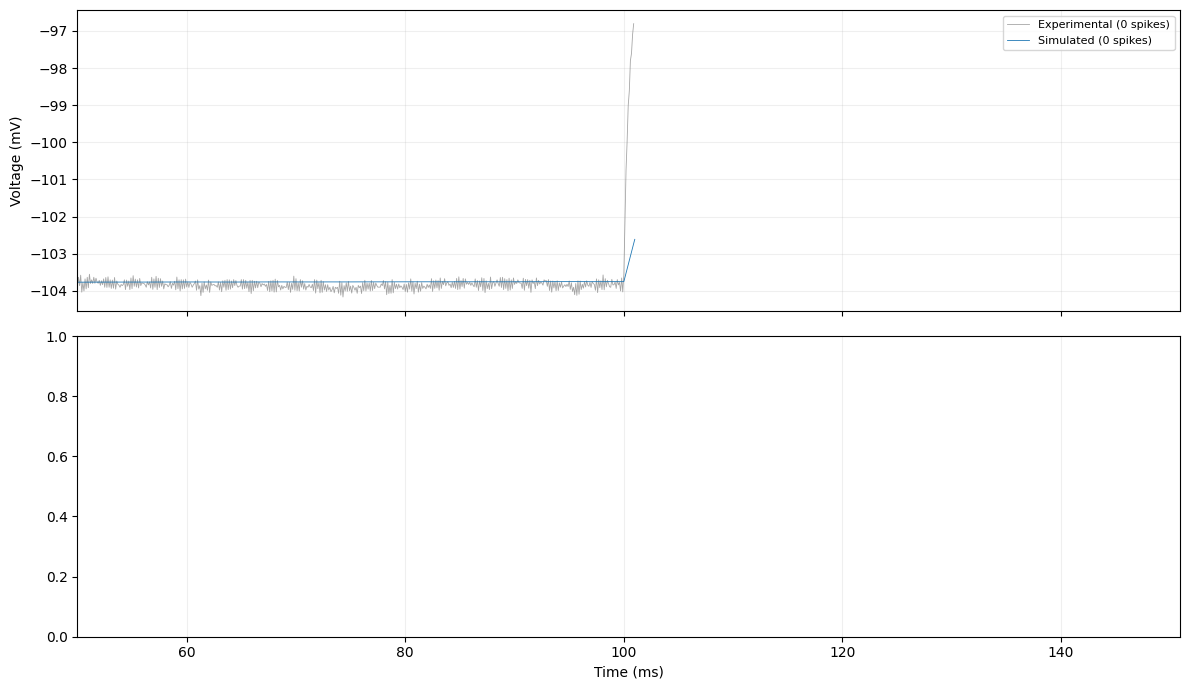

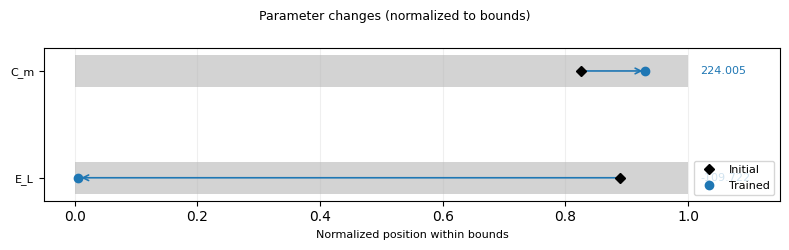

In [9]:
# Evaluate stage 1: simulate and check spike count + Gamma
trained_s1 = result_stage1.get_params_dict()
params_after_s1 = dict(initial_params)
params_after_s1.update(trained_s1)

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);

In [10]:
if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);

# Stage 2

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
{'C_m': 224.00453186035156, 'g_L': 10.0, 'E_L': -109.72178649902344, 'v_T': 0.0, 'delta_T': 1.0, 'v_reset': -100.0, 'v_threshold': 0.0, 'tau_w': 20.0, 'a': 0.0, 'b': 0.0, 'I': 500.0}


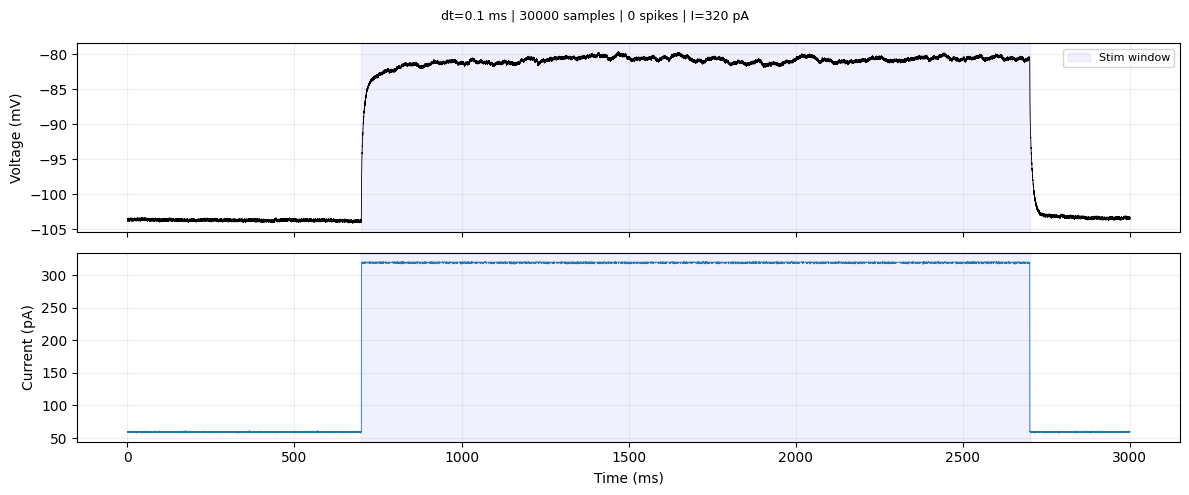

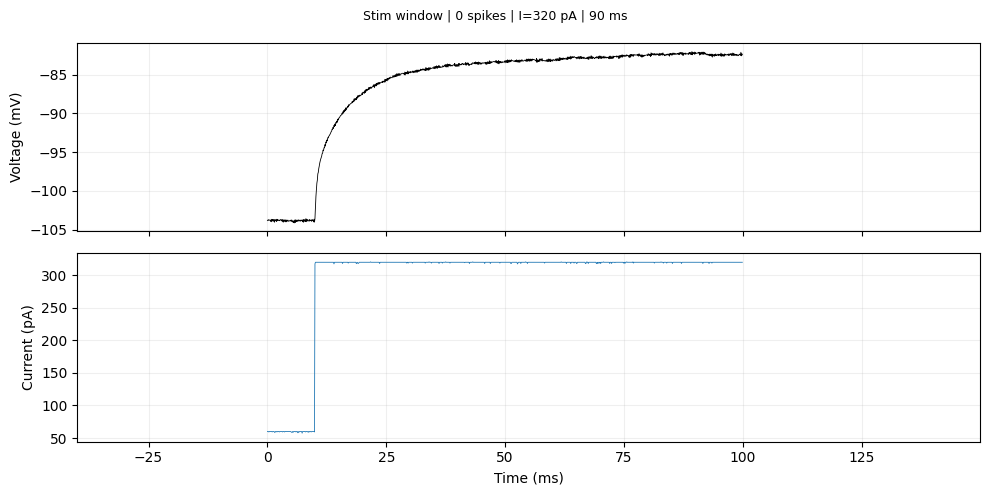

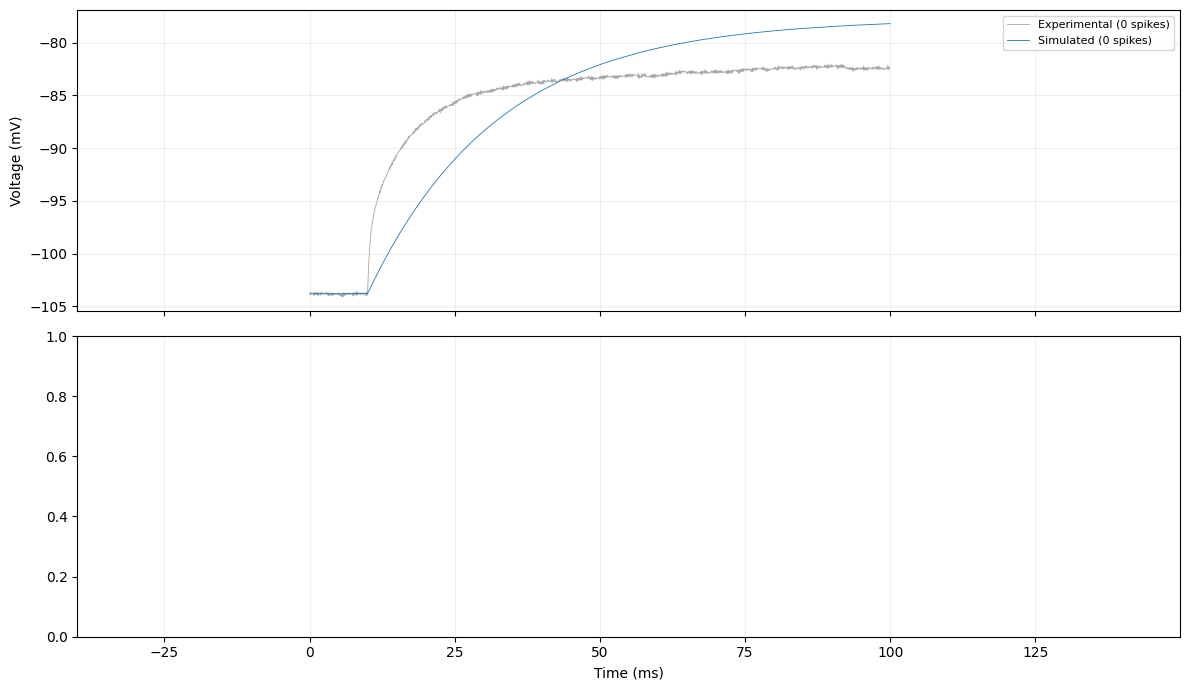

In [11]:
mode = 'subthreshold'

trace = load_trace(
    voltage_path=DATA[mode]['voltage_path'],
    current_path=DATA[mode]['current_path'],
    spike_threshold_mv=-10,
)

trace_plot(trace)

data = crop_to_stim_window(
    trace, max_duration_ms=90.0, padding_ms_before=10.0
)

trace_stim_window_plot(data);

initial_params = params_after_s1.copy()

TRAINABLE_STAGE2 = ["E_L", "g_L"] # 

# Default for unknown parameters in non-spiking setting
initial_params["v_T"] = 0.0
initial_params["delta_T"] = 1.0
initial_params["v_reset"] = -100.0
initial_params["tau_w"] = 20.0
initial_params["a"] = 0.0
initial_params["b"] = 0.0


sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

fit_comparison_plot(data, sim_init)

print(initial_params)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2


Training: optimizer=adam lr=0.1 epochs=2000 surrogate=superspike slope=10.0


Initial MSE loss: 14.3461


Epoch    0 | loss=14.346092 | grad_norm=6.78e+00 | E_L=-109.8218, g_L=10.1000
Epoch  100 | loss=4.075426 | grad_norm=6.95e-01 | E_L=-103.0790, g_L=14.7923
Epoch  200 | loss=1.860120 | grad_norm=2.10e-01 | E_L=-99.5826, g_L=18.3767
Epoch  300 | loss=1.624398 | grad_norm=5.65e-02 | E_L=-98.5314, g_L=19.8458
Epoch  400 | loss=1.604977 | grad_norm=1.32e-02 | E_L=-98.2278, g_L=20.3181
Epoch  500 | loss=1.603852 | grad_norm=2.45e-03 | E_L=-98.1520, g_L=20.4397
Epoch  600 | loss=1.603826 | grad_norm=3.53e-04 | E_L=-98.1371, g_L=20.4638
Epoch  700 | loss=1.603811 | grad_norm=3.97e-05 | E_L=-98.1350, g_L=20.4673
Epoch  800 | loss=1.603798 | grad_norm=5.04e-06 | E_L=-98.1347, g_L=20.4677
Epoch  900 | loss=1.603798 | grad_norm=5.04e-06 | E_L=-98.1347, g_L=20.4677
Epoch 1000 | loss=1.603798 | grad_norm=5.04e-06 | E_L=-98.1347, g_L=20.4677
Epoch 1100 | loss=1.603798 | grad_norm=5.04e-06 | E_L=-98.1347, g_L=20.4677
Epoch 1200 | loss=1.603798 | grad_norm=5.04e-06 | E_L=-98.1347, g_L=20.4677
Epoch 130


Stage 2 complete.
  Best loss:   1.6038
  Total time:  1.5 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 2: 0 spikes (target: 0)
Gamma: N/A (no spikes)


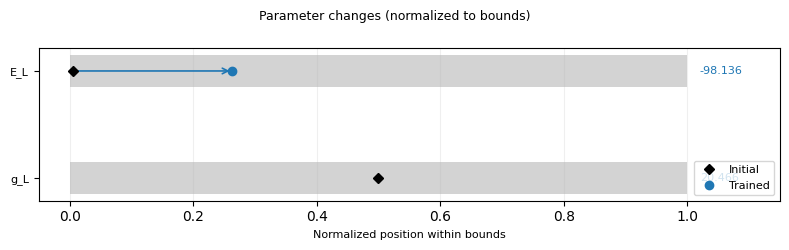

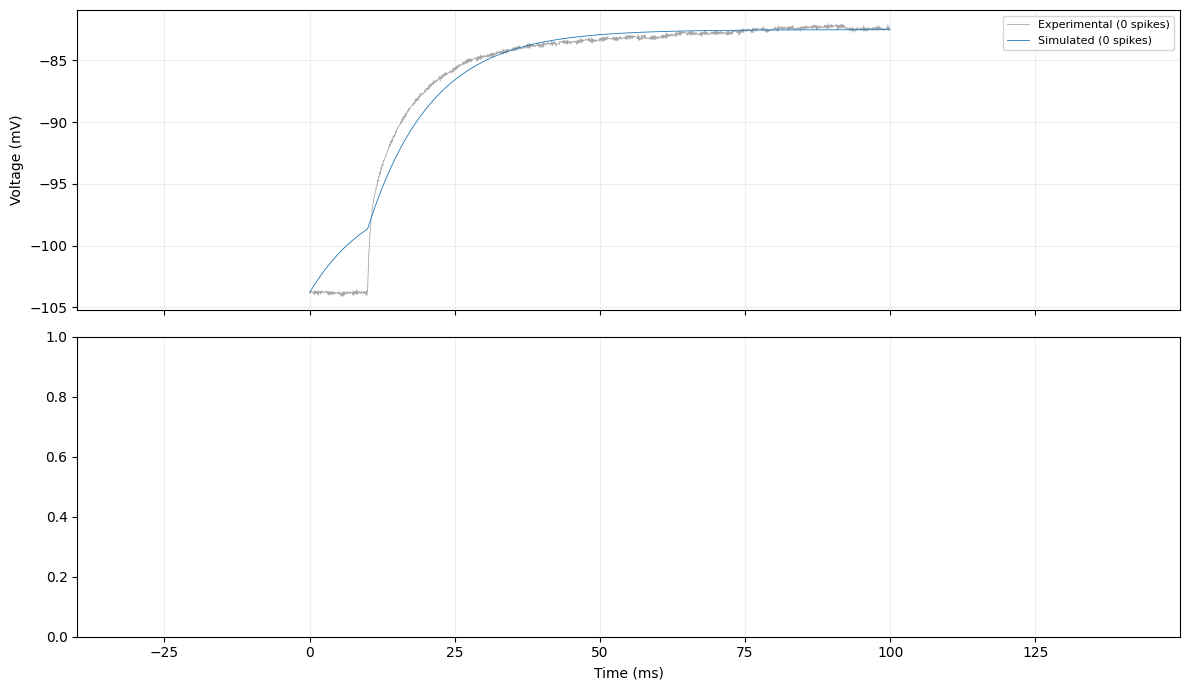

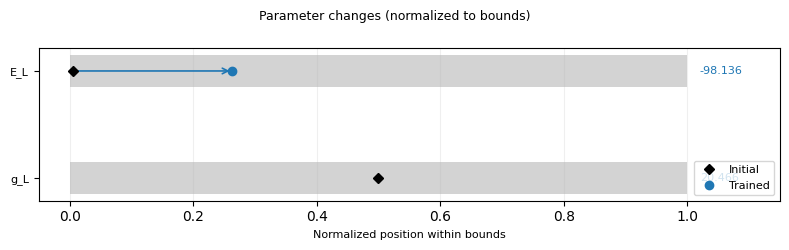

In [12]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_trace_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
exp_voltage = jnp.array(data.voltage)

# --- Stage 1 config: Polyak optimizer, 300 epochs, sigmoid reparameterization ---
config_stage2 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.1,
    n_epochs=2000,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=100,
    #polyak_alpha=1.0,
    #polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=False,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage2,
    trainable_params=TRAINABLE_STAGE2,
)

loss_fn_stage2 = make_mse_loss_fn(cell=cell2, data_stimuli=data_stimuli2, t_max=t_max2, dt_ms=data.dt_ms, exp_voltage=data.voltage, stim_end_index=data.stim_end_idx)

print(f"Initial MSE loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=initial_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

# Evaluate stage 2: simulate and check spike count + Gamma
trained_s2 = result_stage2.get_params_dict()
params_after_s2 = dict(initial_params)
params_after_s2.update(trained_s2)

sim_stage2 = simulate_with_current_trace(
    params=params_after_s2,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 2: {sim_stage2.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage2.n_spikes > 0 and data.n_spikes > 0:
    cf_s2 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage2.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s2.gamma:.3f}")
else:
    cf_s2 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage2)
parameter_comparison_plot(result_stage2)


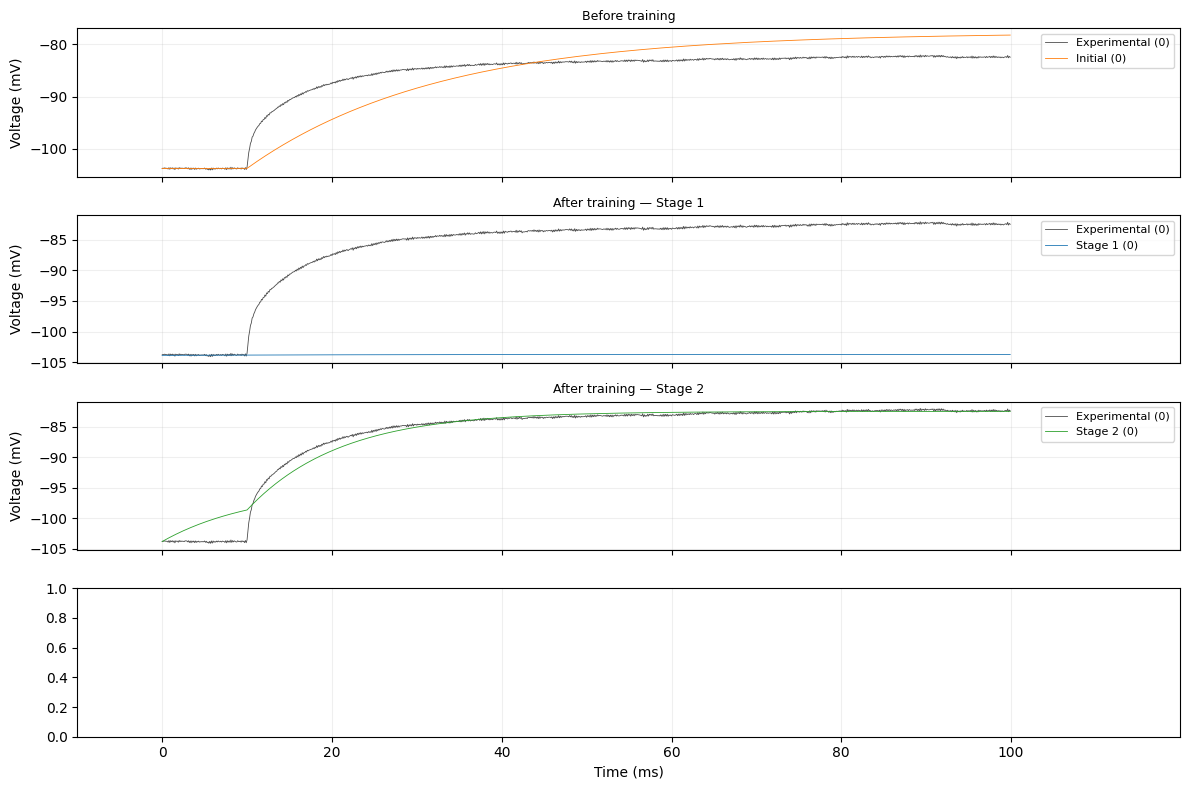

In [13]:
fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1, sim_stage2],
    coincidence=[cf_s1, cf_s2],
    labels=["Stage 1", "Stage 2"],
);

# print(sim_stage1.voltage[1300:1410])

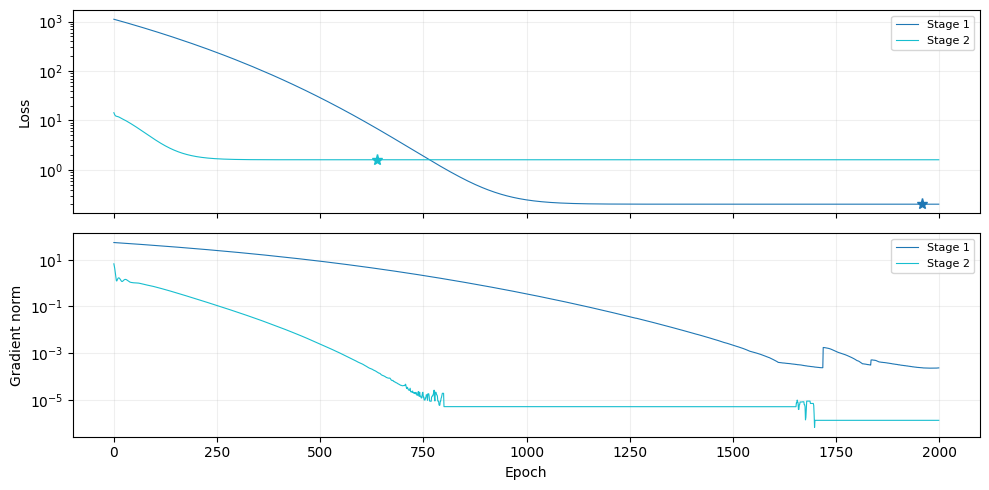

In [14]:
training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1", "Stage 2"],
    show_grad_norms=True,
);

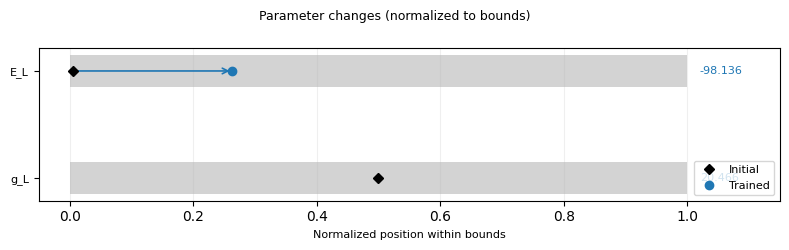

In [15]:
parameter_comparison_plot(result_stage2);

In [16]:
if cf_s2 is not None:
    spike_timing_plot(data, sim_stage2, cf_s2)
else:
    print("Spike timing plot skipped (no spikes)")

Spike timing plot skipped (no spikes)


# Stage 3: Spiking regime — spike initiation (Guarino)
Switch to a spiking trace and fit the spike-initiation parameters (`v_T`, `delta_T`,
`v_reset`) with the Guarino feature loss. Carries over the subthreshold fit (`C_m`,
`E_L`, `g_L`) from Stage 2 and seeds the spike-shape parameters with physiological values.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 7 spikes (target: 3)
{'C_m': 224.00453186035156, 'g_L': 20.465946197509766, 'E_L': -98.13581085205078, 'v_T': -82.0, 'delta_T': 2.0, 'v_reset': -90.0, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 2.0, 'b': 0.0, 'I': 500.0}


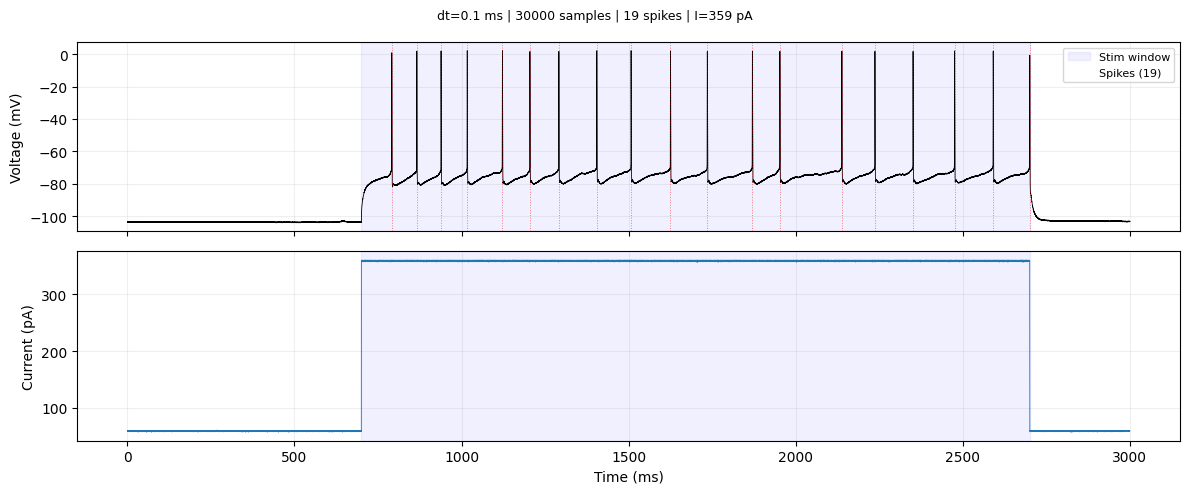

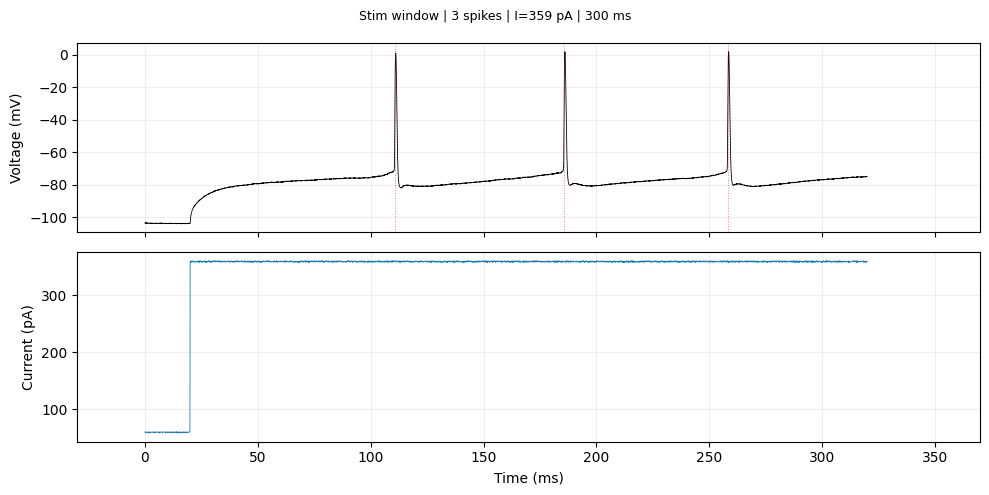

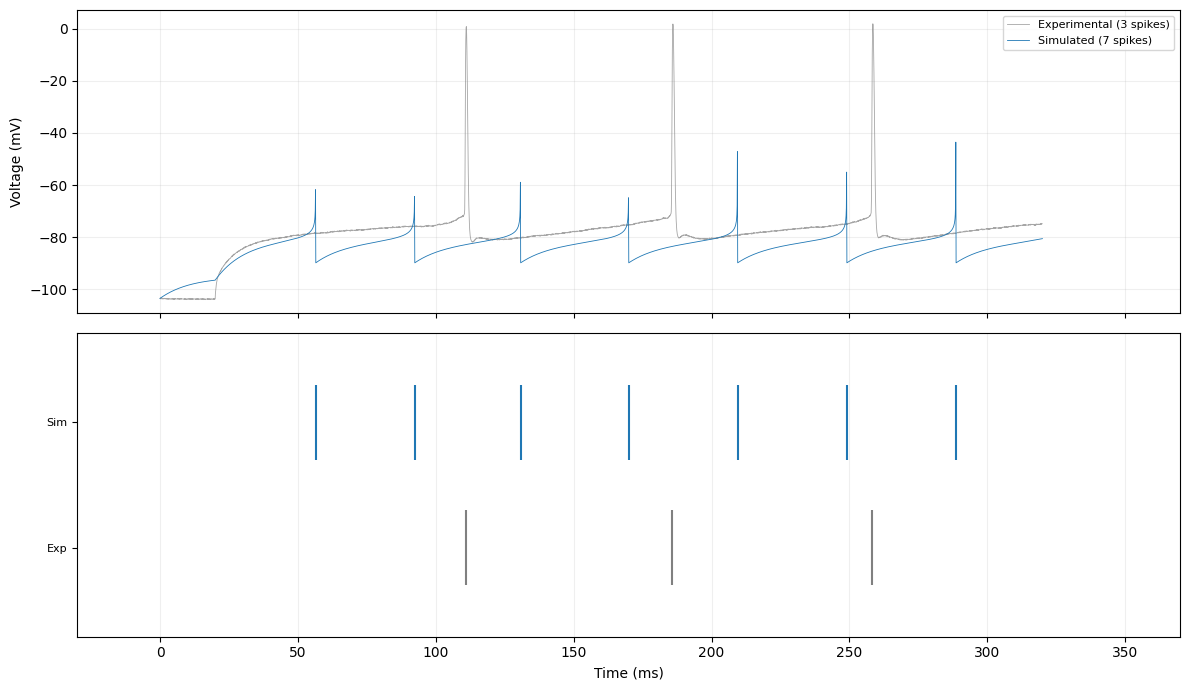

In [17]:
mode = 'stim1'

trace = load_trace(
    voltage_path=DATA[mode]['voltage_path'],
    current_path=DATA[mode]['current_path'],
    spike_threshold_mv=-10,
)

trace_plot(trace)

# Spiking regime: crop to a short window containing a few spikes
# (short window keeps gradients from vanishing over thousands of timesteps)
data = crop_to_stim_window(
    trace, max_duration_ms=300.0, padding_ms_before=20.0
)

trace_stim_window_plot(data)

# Carry over the subthreshold-fit parameters (C_m, E_L, g_L) from stage 2
initial_params = params_after_s2.copy()

TRAINABLE_STAGE3 = ["C_m", "E_L", "g_L", "v_T", "delta_T", "v_reset"]  # spike initiation

# Physiological spiking defaults for the spike-shape / adaptation parameters
initial_params["v_T"] = -82.0
initial_params["delta_T"] = 2.0
initial_params["v_reset"] = -90.0
initial_params["tau_w"] = 30.0
initial_params["a"] = 2.0
initial_params["b"] = 0.0

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


Training: optimizer=adam lr=0.05 epochs=2000 surrogate=superspike slope=10.0


Initial Guarino loss: 7.5135


Epoch    0 | loss=7.513451 | grad_norm=4.30e+00 | C_m=223.9545, E_L=-98.0858, g_L=20.4159, v_T=-82.0500, delta_T=2.0500, v_reset=-89.9500
Epoch  100 | loss=2.469893 | grad_norm=7.68e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  200 | loss=2.469998 | grad_norm=5.27e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  300 | loss=2.469925 | grad_norm=2.23e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  400 | loss=2.469925 | grad_norm=2.23e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  500 | loss=2.469925 | grad_norm=2.23e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  600 | loss=2.469998 | grad_norm=5.27e+00 | C_m=224.3542, E_L=-98.4553, g_L=20.7754, v_T=-81.6894, delta_T=1.7174, v_reset=-89.6398
Epoch  700 | loss=2.469998 | grad_


Stage 3 complete.
  Best loss:   2.4668
  Total time:  4.2 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 3: 4 spikes (target: 3)
Gamma = -0.048


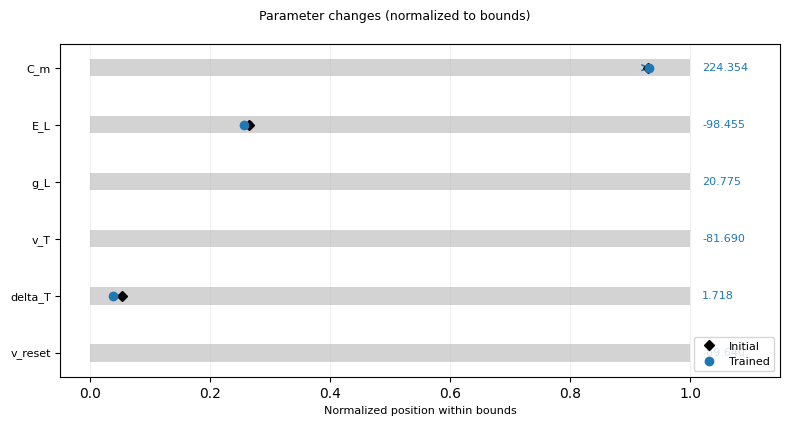

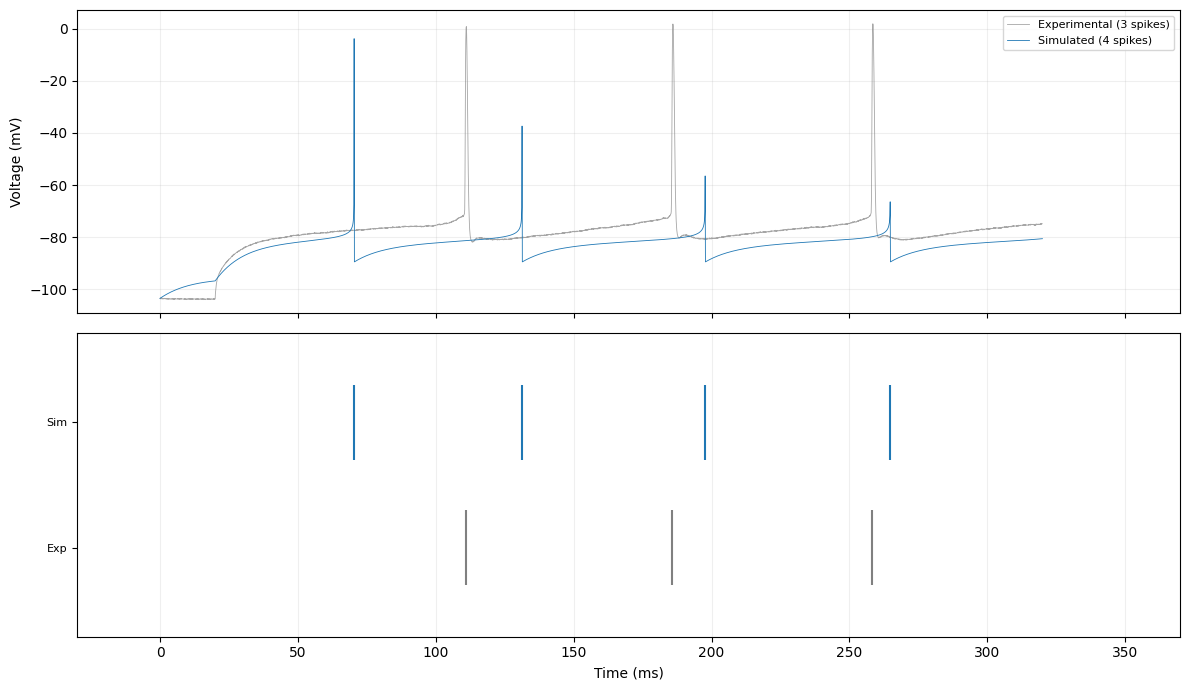

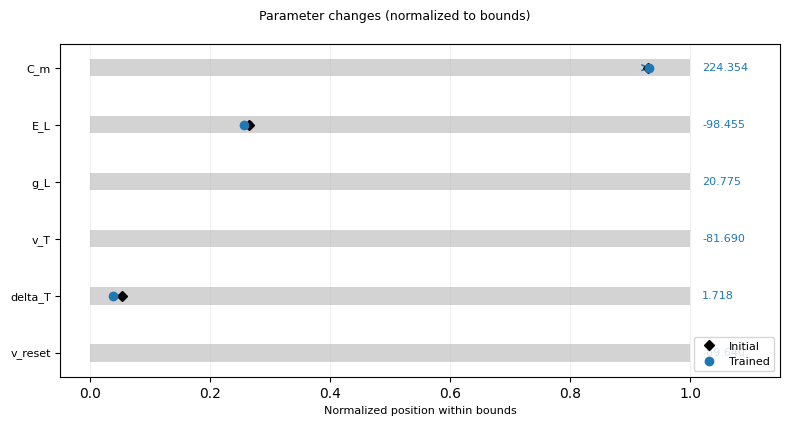

In [18]:
config_stage3 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.05,
    n_epochs=2000,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=100,
    clip_to_bounds=False,
    use_param_transform=False,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell3, data_stimuli3, t_max3, trainable_params3 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage3,
    trainable_params=TRAINABLE_STAGE3,
)

# Guarino feature-based loss for the spiking regime
exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    spike_threshold_mv=-10.0,
)
loss_fn_stage3 = make_guarino_loss_fn(
    cell=cell3, data_stimuli=data_stimuli3, t_max=t_max3, dt_ms=data.dt_ms,
    exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(weight_spike_count=0.1, weight_t_first=3.0),
    temperature=0.3, beta=10, validity_beta=10,
)

print(f"Initial Guarino loss: {float(loss_fn_stage3(trainable_params3)):.4f}")

result_stage3 = train(
    loss_fn=loss_fn_stage3,
    trainable_params=trainable_params3,
    config=config_stage3,
    initial_params=initial_params,
)

print(f"\nStage 3 complete.")
print(f"  Best loss:   {result_stage3.best_loss:.4f}")
print(f"  Total time:  {result_stage3.total_time:.1f} s")

# Evaluate stage 3
trained_s3 = result_stage3.get_params_dict()
params_after_s3 = dict(initial_params)
params_after_s3.update(trained_s3)

sim_stage3 = simulate_with_current_trace(
    params=params_after_s3,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 3: {sim_stage3.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage3.n_spikes > 0 and data.n_spikes > 0:
    cf_s3 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage3.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s3.gamma:.3f}")
else:
    cf_s3 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage3)
parameter_comparison_plot(result_stage3)

# Stage 4: Spiking regime — adaptation (Guarino)
Move to a higher-current spiking trace (richer adaptation dynamics) and fit the
adaptation parameters (`tau_w`, `a`, `b`) with the Guarino feature loss. Carries over
everything fit so far (`C_m`, `E_L`, `g_L`, `v_T`, `delta_T`, `v_reset`) from Stage 3.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 11 spikes (target: 7)
{'C_m': 224.353515625, 'g_L': 20.7747745513916, 'E_L': -98.45462036132812, 'v_T': -81.6900634765625, 'delta_T': 1.7180126905441284, 'v_reset': -89.64017486572266, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 2.0, 'b': 0.0, 'I': 500.0}


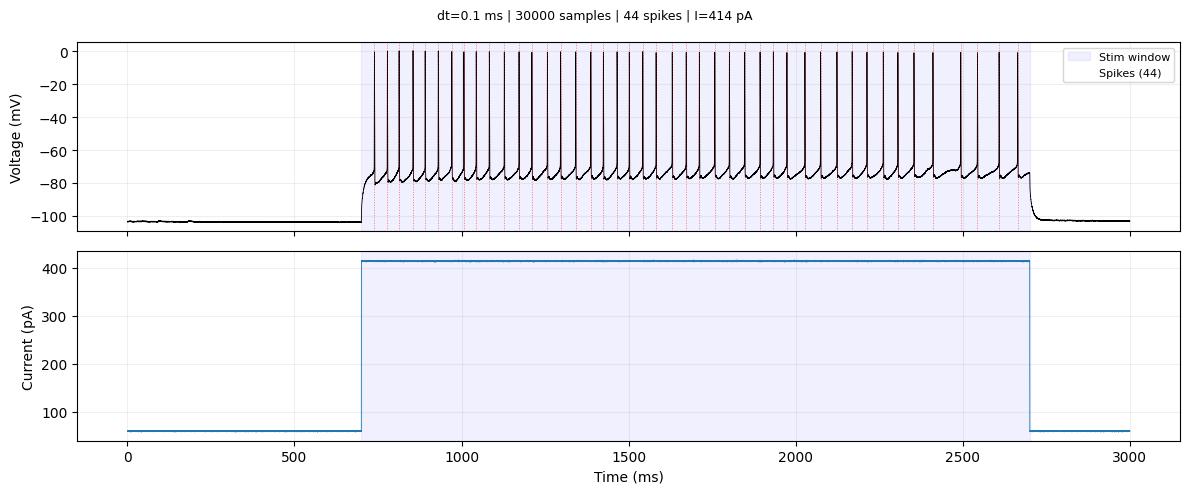

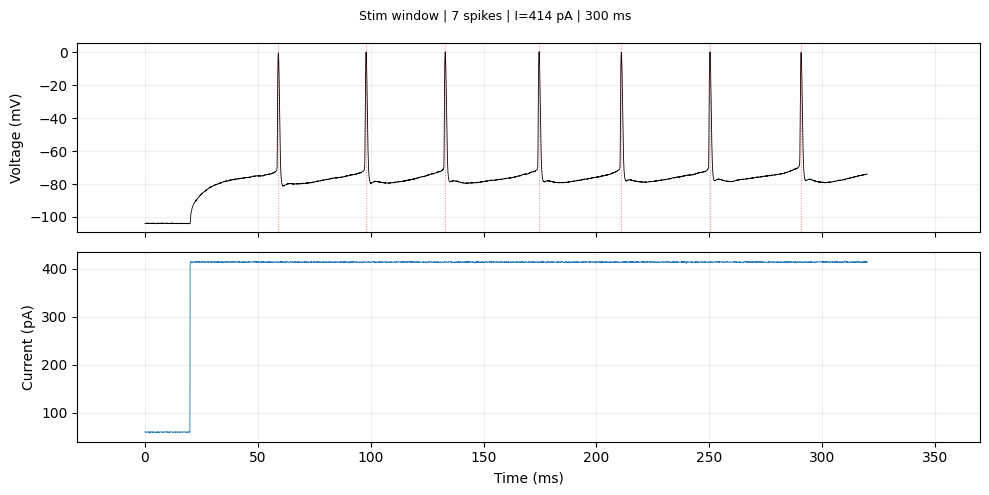

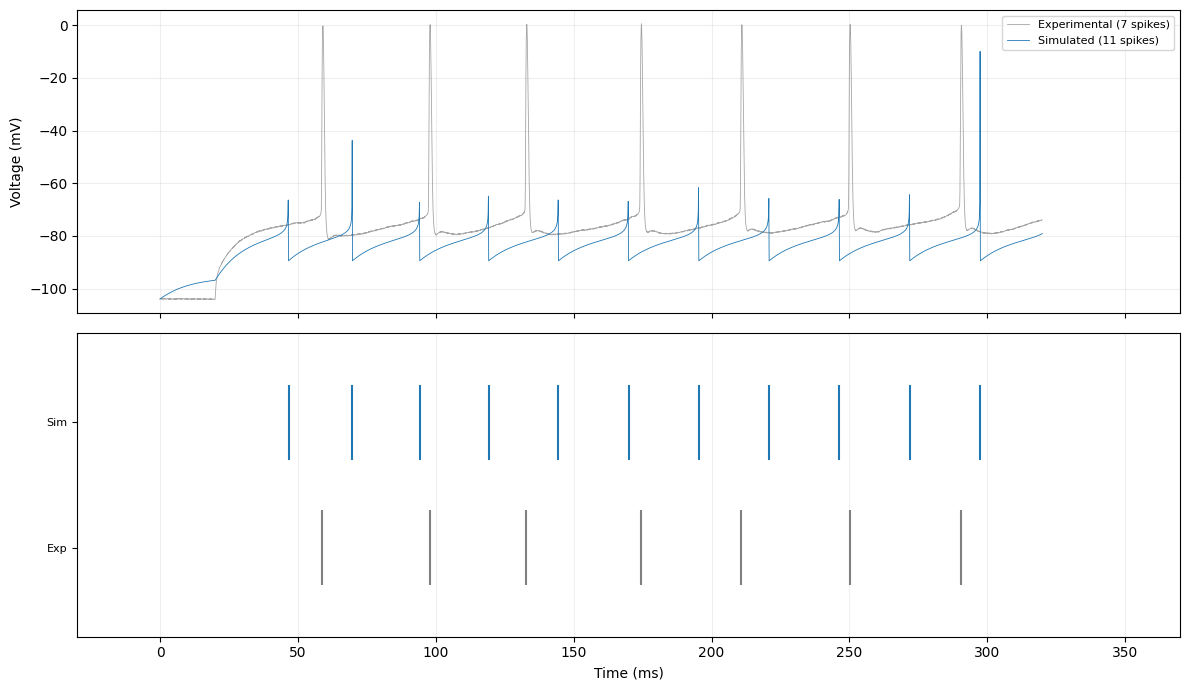

In [19]:
mode = 'stim2'

trace = load_trace(
    voltage_path=DATA[mode]['voltage_path'],
    current_path=DATA[mode]['current_path'],
    spike_threshold_mv=-10,
)

trace_plot(trace)

data = crop_to_stim_window(
    trace, max_duration_ms=300.0, padding_ms_before=20.0
)

trace_stim_window_plot(data)

# Carry over all previously fit parameters from stage 3
initial_params = params_after_s3.copy()

TRAINABLE_STAGE4 = ["C_m", "g_L", "E_L", "v_T", "delta_T", "v_reset", "tau_w", "a", "b"]  # adaptation

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

Training: optimizer=adam lr=0.1 epochs=10000 surrogate=superspike slope=10.0


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9
Initial Guarino loss: 4.7232


Epoch    0 | loss=4.723213 | grad_norm=2.19e+07 | C_m=224.4535, g_L=20.8748, E_L=-98.5546, v_T=-81.5901, delta_T=1.8180, v_reset=-89.5402, tau_w=29.9000, a=2.1000, b=0.1000
Epoch  100 | loss=4.708869 | grad_norm=1.47e+01 | C_m=224.2794, g_L=20.7236, E_L=-98.3765, v_T=-81.7240, delta_T=3.0195, v_reset=-90.0025, tau_w=29.4082, a=2.2245, b=1.4188
Epoch  200 | loss=4.714445 | grad_norm=4.78e-01 | C_m=224.2682, g_L=20.7151, E_L=-98.3667, v_T=-81.7324, delta_T=3.0268, v_reset=-90.0278, tau_w=29.4200, a=2.2317, b=1.4464
Epoch  300 | loss=4.714445 | grad_norm=4.78e-01 | C_m=224.2682, g_L=20.7151, E_L=-98.3667, v_T=-81.7324, delta_T=3.0268, v_reset=-90.0278, tau_w=29.4200, a=2.2317, b=1.4464
Epoch  400 | loss=4.714445 | grad_norm=4.68e-01 | C_m=224.2682, g_L=20.7151, E_L=-98.3667, v_T=-81.7324, delta_T=3.0268, v_reset=-90.0278, tau_w=29.4200, a=2.2317, b=1.4464
Epoch  500 | loss=4.714446 | grad_norm=4.32e-01 | C_m=224.2682, g_L=20.7151, E_L=-98.3667, v_T=-81.7324, delta_T=3.0268, v_reset=-90.02


Stage 4 complete.
  Best loss:   0.4340
  Total time:  18.3 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 4: 7 spikes (target: 7)
Gamma = 0.212


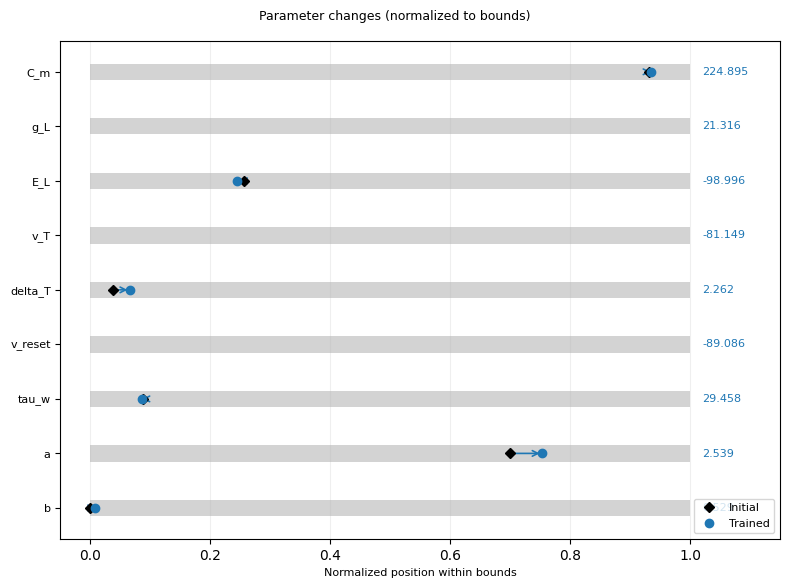

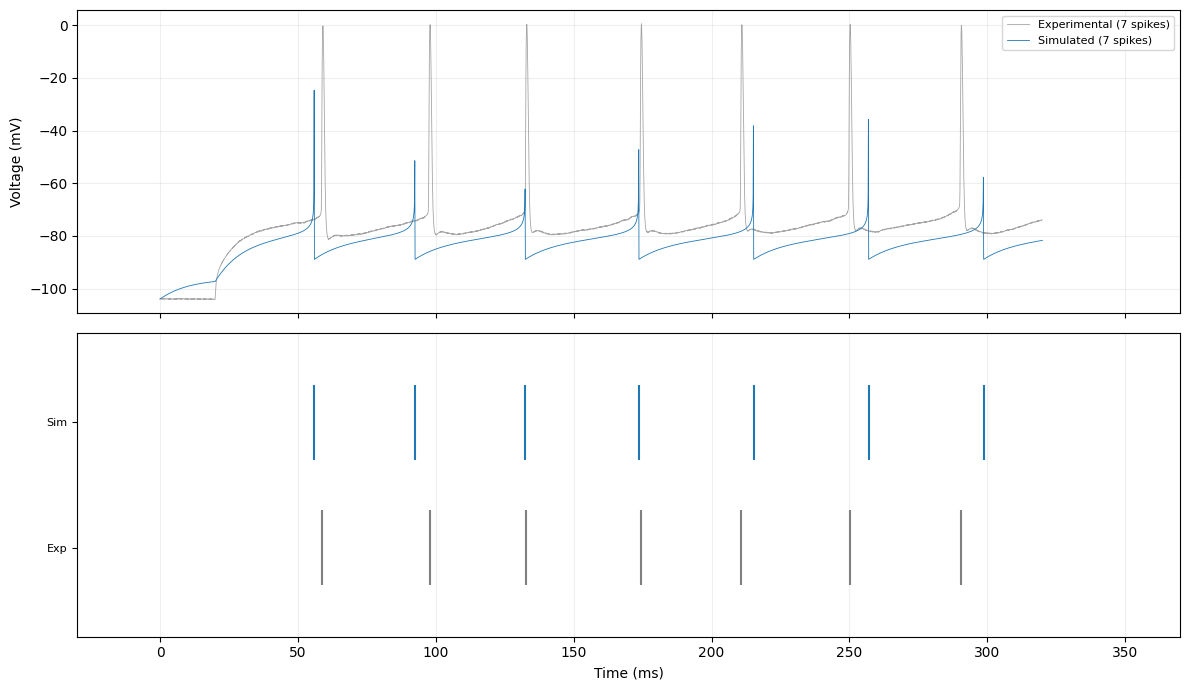

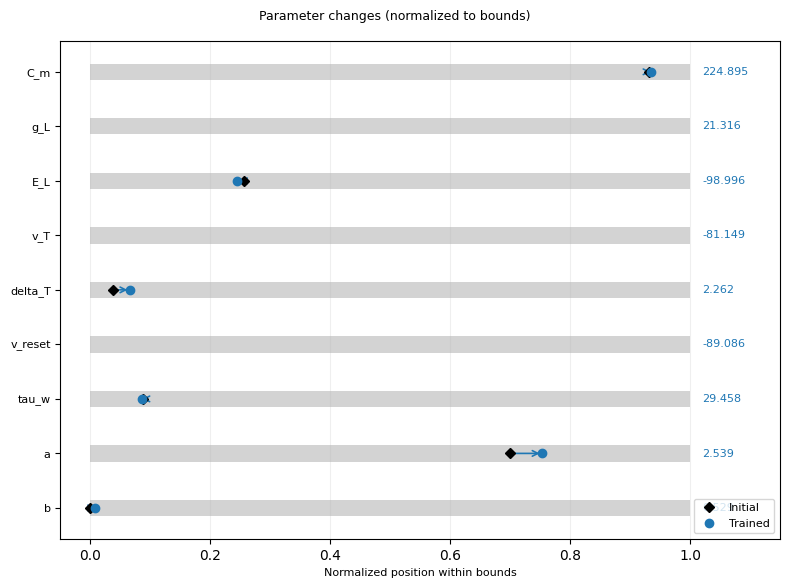

In [20]:
config_stage4 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.1,
    n_epochs=10000,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=100,
    clip_to_bounds=False,
    use_param_transform=False,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell4, data_stimuli4, t_max4, trainable_params4 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage4,
    trainable_params=TRAINABLE_STAGE4,
)

# Guarino feature-based loss for the spiking regime
exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    spike_threshold_mv=-10.0,
)
loss_fn_stage4 = make_guarino_loss_fn(
    cell=cell4, data_stimuli=data_stimuli4, t_max=t_max4, dt_ms=data.dt_ms,
    exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(weight_spike_count=0.1, weight_t_first=3.0),
    temperature=0.3, beta=10, validity_beta=10,
)

print(f"Initial Guarino loss: {float(loss_fn_stage4(trainable_params4)):.4f}")

result_stage4 = train(
    loss_fn=loss_fn_stage4,
    trainable_params=trainable_params4,
    config=config_stage4,
    initial_params=initial_params,
)

print(f"\nStage 4 complete.")
print(f"  Best loss:   {result_stage4.best_loss:.4f}")
print(f"  Total time:  {result_stage4.total_time:.1f} s")

# Evaluate stage 4
trained_s4 = result_stage4.get_params_dict()
params_after_s4 = dict(initial_params)
params_after_s4.update(trained_s4)

sim_stage4 = simulate_with_current_trace(
    params=params_after_s4,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 4: {sim_stage4.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage4.n_spikes > 0 and data.n_spikes > 0:
    cf_s4 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage4.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s4.gamma:.3f}")
else:
    cf_s4 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage4)
parameter_comparison_plot(result_stage4)

# Summary: all stages
Loss histories across the four-stage curriculum (the loss *type* differs between the
subthreshold MSE stages and the spiking Guarino stages, so absolute values are not
directly comparable — read each stage's trend, not cross-stage levels).

Final fitted parameters:
         C_m: 224.8954
         g_L: 21.3161
         E_L: -98.9961
         v_T: -81.1487
     delta_T: 2.2621
     v_reset: -89.0861
  v_threshold: 0.0000
       tau_w: 29.4577
           a: 2.5391
           b: 0.5291
           I: 500.0000


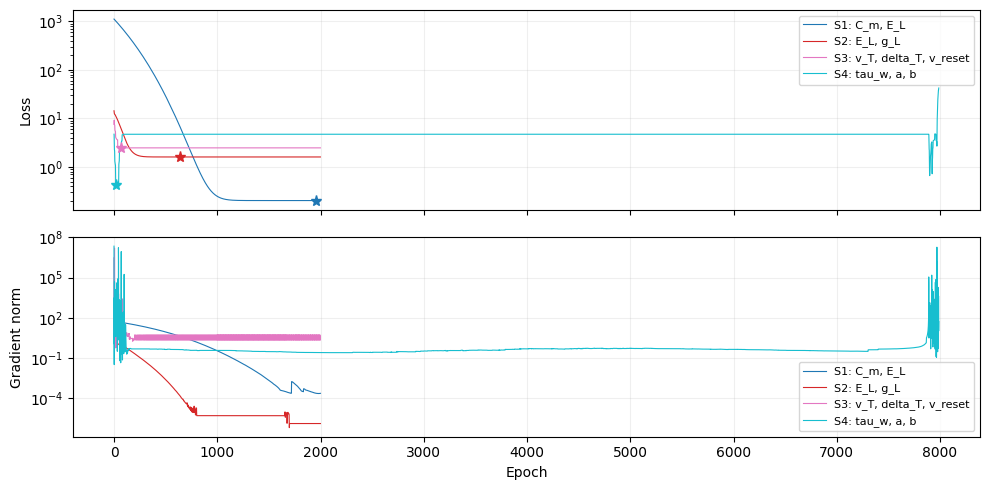

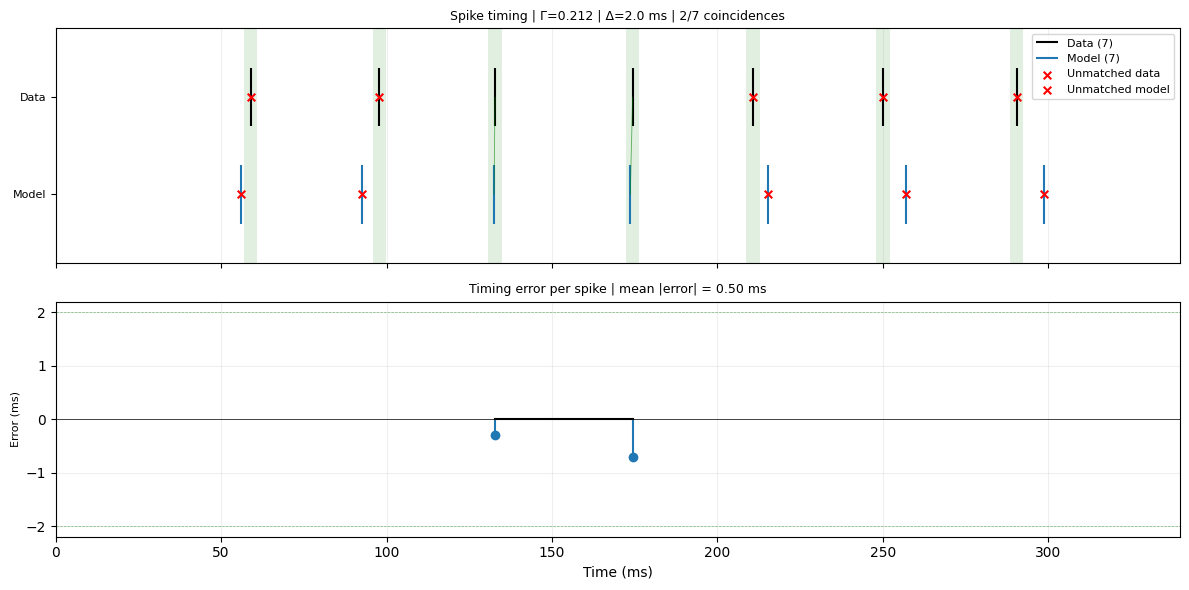

In [21]:
training_comparison_plot(
    [result_stage1, result_stage2, result_stage3, result_stage4],
    labels=[
        "S1: C_m, E_L",
        "S2: E_L, g_L",
        "S3: v_T, delta_T, v_reset",
        "S4: tau_w, a, b",
    ],
    show_grad_norms=True,
)

if cf_s4 is not None:
    spike_timing_plot(data, sim_stage4, cf_s4)

print("Final fitted parameters:")
for k, v in params_after_s4.items():
    print(f"  {k:>10}: {v:.4f}")